# Predicting Heart Disease Using Logistic Regression

### 1. Data Preparation:

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('heart_disease_uci.csv')

In [2]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [6]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df[['num','thal']].value_counts()

num  thal             
0    normal               138
1    reversable defect     63
3    reversable defect     43
0    reversable defect     38
2    reversable defect     37
1    normal                30
2    normal                14
1    fixed defect          13
2    fixed defect          12
3    normal                12
0    fixed defect          11
4    reversable defect     11
3    fixed defect           7
4    fixed defect           3
     normal                 2
Name: count, dtype: int64

In [11]:
# Create binary classification target (most common approach) as num=0 (no disease) vs num>0 (disease)
df['heart_disease'] = (df['num'] > 0).astype(int)

print("Binary target distribution:")
print(df['heart_disease'].value_counts(normalize=True))

print("\nOriginal 'num' distribution:")
print(df['num'].value_counts().sort_index())

Binary target distribution:
heart_disease
1    0.553261
0    0.446739
Name: proportion, dtype: float64

Original 'num' distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [12]:
# Encode 'thal' (categorical feature)
thal_mapping = {
    'normal': 0,
    'fixed defect': 1,
    'reversable defect': 2
}
df['thal_encoded'] = df['thal'].map(thal_mapping)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             920 non-null    int64  
 1   age            920 non-null    int64  
 2   sex            920 non-null    object 
 3   dataset        920 non-null    object 
 4   cp             920 non-null    object 
 5   trestbps       861 non-null    float64
 6   chol           890 non-null    float64
 7   fbs            830 non-null    object 
 8   restecg        918 non-null    object 
 9   thalch         865 non-null    float64
 10  exang          865 non-null    object 
 11  oldpeak        858 non-null    float64
 12  slope          611 non-null    object 
 13  ca             309 non-null    float64
 14  thal           434 non-null    object 
 15  num            920 non-null    int64  
 16  heart_disease  920 non-null    int32  
 17  thal_encoded   434 non-null    float64
dtypes: float64

In [16]:
df_drop = df.copy()
df_drop = df_drop.dropna(thresh=1)

In [17]:
df_drop.shape

(920, 18)


Cross-tabulation: thal vs num
num                  0   1   2   3   4
thal                                  
fixed defect        11  13  12   7   3
normal             138  30  14  12   2
reversable defect   38  63  37  43  11


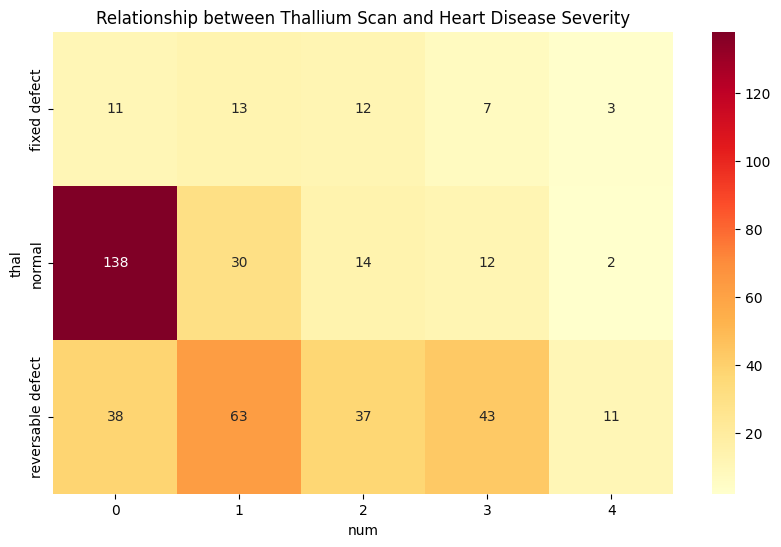

<Figure size 1000x600 with 0 Axes>

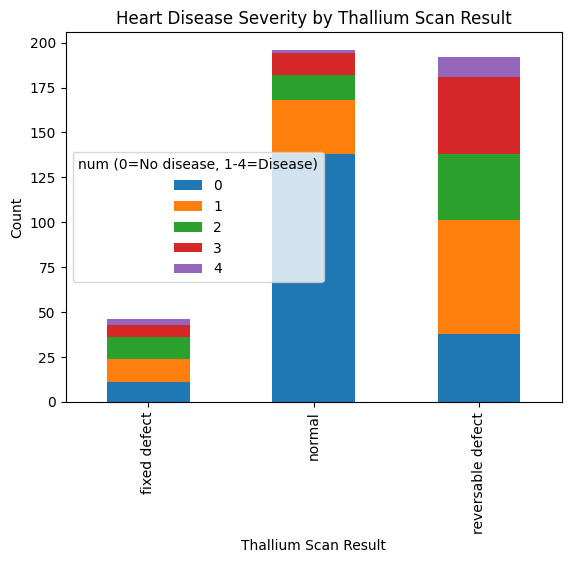

In [18]:
import seaborn as sns

# Cross-tabulation
cross_tab = pd.crosstab(df['thal'], df['num'])
print("\nCross-tabulation: thal vs num")
print(cross_tab)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Relationship between Thallium Scan and Heart Disease Severity')
plt.show()

# Bar chart
plt.figure(figsize=(10, 6))
df.groupby(['thal', 'num']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Heart Disease Severity by Thallium Scan Result')
plt.xlabel('Thallium Scan Result')
plt.ylabel('Count')
plt.legend(title='num (0=No disease, 1-4=Disease)')
plt.show()

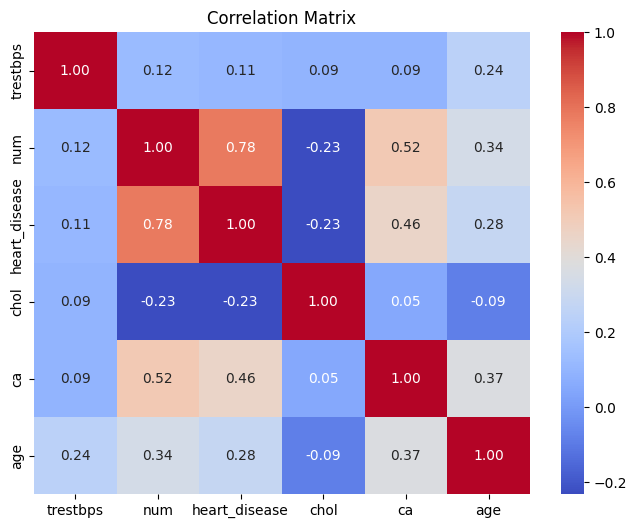

In [23]:
corr_matrix = df[['trestbps', 'num', 'heart_disease', 'chol', 'ca', 'age']].corr()
corr_matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [28]:
print(df.isnull().sum())

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps          59
chol              30
fbs               90
restecg            2
thalch            55
exang             55
oldpeak           62
slope            309
ca               611
thal             486
num                0
heart_disease      0
thal_encoded     486
dtype: int64


In [30]:
df['thal_encoded']

0      1.0
1      0.0
2      2.0
3      0.0
4      0.0
      ... 
915    NaN
916    NaN
917    1.0
918    NaN
919    NaN
Name: thal_encoded, Length: 920, dtype: float64

In [32]:
df['thal_missing'] = df['thal_encoded'].isna().astype(int)
df['thal_encoded_filled'] = df['thal_encoded'].fillna(df['thal_encoded'].median())

In [33]:
df['thal_encoded_filled']

0      1.0
1      0.0
2      2.0
3      0.0
4      0.0
      ... 
915    1.0
916    1.0
917    1.0
918    1.0
919    1.0
Name: thal_encoded_filled, Length: 920, dtype: float64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   920 non-null    int64  
 1   age                  920 non-null    int64  
 2   sex                  920 non-null    object 
 3   dataset              920 non-null    object 
 4   cp                   920 non-null    object 
 5   trestbps             861 non-null    float64
 6   chol                 890 non-null    float64
 7   fbs                  830 non-null    object 
 8   restecg              918 non-null    object 
 9   thalch               865 non-null    float64
 10  exang                865 non-null    object 
 11  oldpeak              858 non-null    float64
 12  slope                611 non-null    object 
 13  ca                   309 non-null    float64
 14  thal                 434 non-null    object 
 15  num                  920 non-null    int

In [36]:
df.drop(columns=['thal', 'thal_encoded'], inplace=True)

In [38]:
df['slope'].fillna('unknown', inplace=True)

In [41]:
df['ca'].fillna(df['ca'].median(), inplace=True)

In [45]:
df[['trestbps', 'chol', 'fbs', 'thalch']].fillna(df[['trestbps', 'chol', 'fbs', 'thalch']].mode(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_15184\3284823436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['trestbps', 'chol', 'fbs', 'thalch']].fillna(df[['trestbps', 'chol', 'fbs', 'thalch']].mode(), inplace=True)


In [47]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   920 non-null    int64  
 1   age                  920 non-null    int64  
 2   sex                  920 non-null    object 
 3   dataset              920 non-null    object 
 4   cp                   920 non-null    object 
 5   trestbps             861 non-null    float64
 6   chol                 890 non-null    float64
 7   fbs                  830 non-null    object 
 8   restecg              918 non-null    object 
 9   thalch               865 non-null    float64
 10  exang                865 non-null    object 
 11  oldpeak              858 non-null    float64
 12  slope                920 non-null    object 
 13  ca                   920 non-null    float64
 14  num                  920 non-null    int64  
 15  heart_disease        920 non-null    int

In [49]:
df['trestbps'].fillna(df['trestbps'].mean(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_15184\2222330963.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(df['trestbps'].mean(), inplace=True)


In [51]:
df['trestbps'].isnull

<bound method Series.isnull of 0      145.0
1      160.0
2      120.0
3      130.0
4      130.0
       ...  
915    127.0
916    120.0
917    122.0
918    120.0
919    120.0
Name: trestbps, Length: 920, dtype: float64>

In [55]:
df['sex'].replace({'Male':0, 'Female':1}, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_15184\885912017.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'].replace({'Male':0, 'Female':1}, inplace=True)


In [56]:
df['sex'].value_counts()

sex
0    726
1    194
Name: count, dtype: int64

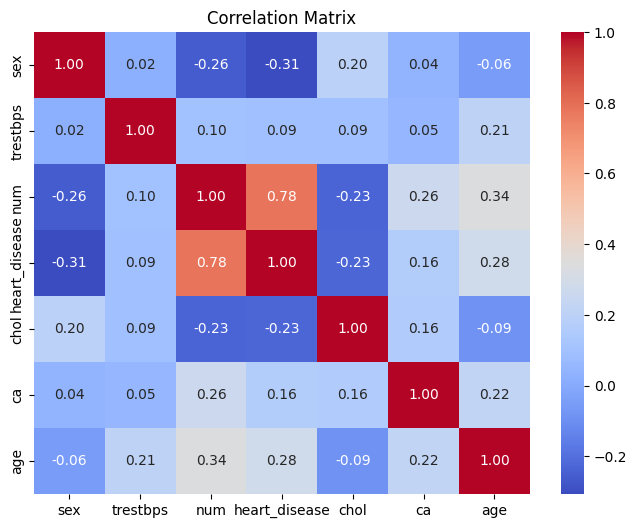

In [57]:
corr_matrix = df[['sex','trestbps', 'num', 'heart_disease', 'chol', 'ca', 'age']].corr()
corr_matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [67]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 919
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   743 non-null    int64  
 1   age                  743 non-null    int64  
 2   sex                  743 non-null    int64  
 3   dataset              743 non-null    object 
 4   cp                   743 non-null    object 
 5   trestbps             743 non-null    float64
 6   chol                 743 non-null    float64
 7   fbs                  743 non-null    object 
 8   restecg              743 non-null    object 
 9   thalch               743 non-null    float64
 10  exang                743 non-null    object 
 11  oldpeak              743 non-null    float64
 12  slope                743 non-null    object 
 13  ca                   743 non-null    float64
 14  num                  743 non-null    int64  
 15  heart_disease        743 non-null    int32  


In [76]:
# Get numeric column names
num_columns = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
df[num_columns].dropna(inplace=True)

X = df[num_columns].drop(columns=['id','num', 'heart_disease'])


y = df['heart_disease']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures in X: {X.columns.tolist()}")


X shape: (743, 9)
y shape: (743,)

Features in X: ['age', 'sex', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'thal_missing', 'thal_encoded_filled']


C:\Users\hp\AppData\Local\Temp\ipykernel_15184\3064198970.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_columns].dropna(inplace=True)


In [77]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model, metrics

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(594, 9) (149, 9) (594,) (149,)


In [78]:
model = linear_model.LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {score:.4f}")

Accuracy: 0.7852


In [82]:
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.7711
Recall: 0.8312
F1 Score: 0.8000


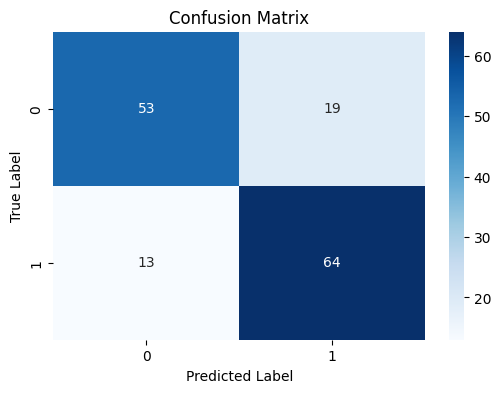

In [81]:
confusion_mtx = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [87]:
high_risk_patient = {
    'age': 65,
    'sex': 1,
    'trestbps': 180,
    'chol': 300,
    'thalch': 100,
    'oldpeak': 4.0,
    'ca': 3,
    'thal_missing': 0,
    'thal_encoded_filled': 2.0
}

# Predict
df = pd.DataFrame([high_risk_patient])
prediction = model.predict(df)[0]
print(f"Prediction: {prediction} (1 = Has heart disease)")  # Should output 1

Prediction: 1 (1 = Has heart disease)


In [ ]:
low_risk_patient = {
    'age': 30,
    'sex': 0,
    'trestbps': 110,
    'chol': 160,
    'thalch': 180,
    'oldpeak': 0.0,
    'ca': 0,
    'thal_missing': 0,
    'thal_encoded_filled': 0.0
}

# Predict
df = pd.DataFrame([low_risk_patient])
prediction = model.predict(df)[0]
print(f"Prediction: {prediction} (0 = No heart disease)")  # Should output 0

Prediction: 0 (0 = No heart disease)
